<a href="https://colab.research.google.com/github/shahwaiz-9/Deep-Learning/blob/main/Research_Paper_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**DEPENDCIES**

## Dependencies

In [ ]:
import kagglehub
import os

In [ ]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px

In [ ]:
from PIL import Image

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, f1_score, recall_score, precision_score, accuracy_score
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import v2
from PIL import Image
import torchvision.models as models
from pytorch_grad_cam import GradCAM, HiResCAM, ScoreCAM, GradCAMPlusPlus, AblationCAM, XGradCAM, EigenCAM, FullGrad
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive

In [ ]:
import cv2

In [ ]:
import time
import random

**DATASET LOADING**

## Dataset Loading

In [1]:


# Download latest version
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Path to dataset files: /kaggle/input/brain-tumor-mri-dataset


In [2]:


print(f"Contents of {path}:")
for item in os.listdir(path):
    item_path = os.path.join(path, item)
    if os.path.isdir(item_path):
        print(f"  [DIR] {item} (contains {len(os.listdir(item_path))} items)")
        for sub_item in os.listdir(item_path):
            sub_item_path = os.path.join(item_path, sub_item)
            if os.path.isdir(sub_item_path):
                print(f"    [SUB-DIR] {sub_item} (contains {len(os.listdir(sub_item_path))} items)")
            else:
                print(f"    [FILE] {sub_item}")
    else:
        print(f"  [FILE] {item}")

Contents of /kaggle/input/brain-tumor-mri-dataset:
  [DIR] Training (contains 4 items)
    [SUB-DIR] pituitary (contains 1400 items)
    [SUB-DIR] notumor (contains 1400 items)
    [SUB-DIR] meningioma (contains 1400 items)
    [SUB-DIR] glioma (contains 1400 items)
  [DIR] Testing (contains 4 items)
    [SUB-DIR] pituitary (contains 400 items)
    [SUB-DIR] notumor (contains 400 items)
    [SUB-DIR] meningioma (contains 400 items)
    [SUB-DIR] glioma (contains 400 items)


In [3]:

base_dir = path

def collect_image_paths_and_labels(data_dir):
    images = []
    labels = []
    for subdir in os.listdir(data_dir):
        subdir_path = os.path.join(data_dir, subdir)
        if os.path.isdir(subdir_path):
            for file in os.listdir(subdir_path):
                if file.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
                    images.append(os.path.join(subdir_path, file))
                    labels.append(subdir)
    return images, labels

# Collect data for Training set
training_dir = os.path.join(base_dir, 'Training')
train_images, train_labels = collect_image_paths_and_labels(training_dir)
train_df = pd.DataFrame({'filepath': train_images, 'label': train_labels, 'set': 'train'})

# Collect data for Testing set
testing_dir = os.path.join(base_dir, 'Testing')
test_images, test_labels = collect_image_paths_and_labels(testing_dir)
test_df = pd.DataFrame({'filepath': test_images, 'label': test_labels, 'set': 'test'})

# Concatenate both dataframes
dataset_df = pd.concat([train_df, test_df], ignore_index=True)

print("Dataset DataFrame head:")
print(dataset_df.head())
print("\nDataset DataFrame info:")
print(dataset_df.info())
print("\nNumber of images per class (Training set):")
print(train_df['label'].value_counts())
print("\nNumber of images per class (Testing set):")
print(test_df['label'].value_counts())

Dataset DataFrame head:
                                            filepath      label    set
0  /kaggle/input/brain-tumor-mri-dataset/Training...  pituitary  train
1  /kaggle/input/brain-tumor-mri-dataset/Training...  pituitary  train
2  /kaggle/input/brain-tumor-mri-dataset/Training...  pituitary  train
3  /kaggle/input/brain-tumor-mri-dataset/Training...  pituitary  train
4  /kaggle/input/brain-tumor-mri-dataset/Training...  pituitary  train

Dataset DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7200 entries, 0 to 7199
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   filepath  7200 non-null   object
 1   label     7200 non-null   object
 2   set       7200 non-null   object
dtypes: object(3)
memory usage: 168.9+ KB
None

Number of images per class (Training set):
label
pituitary     1400
notumor       1400
meningioma    1400
glioma        1400
Name: count, dtype: int64

Number of images per class (T

## Data Exploration

In [4]:

# Overall label distribution
overall_label_counts = dataset_df['label'].value_counts().reset_index()
overall_label_counts.columns = ['Label', 'Count']

# Define a custom color palette
custom_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] # Blue, Orange, Green, Red

fig_overall = px.bar(overall_label_counts,
                     x='Label',
                     y='Count',
                     title='<b>Overall Distribution of Brain Tumor MRI Labels</b>', # Bold title
                     color='Label', # Color bars by label
                     color_discrete_sequence=custom_colors, # Apply custom colors
                     text='Count' # Display count on top of bars
                    )
fig_overall.update_traces(texttemplate='%{text}', textposition='outside') # Customize text position
fig_overall.update_layout(title_x=0.5, # Center the title
                          xaxis_title='Tumor Type',
                          yaxis_title='Number of Images',
                          uniformtext_minsize=8, uniformtext_mode='hide', # Hide text if it doesn't fit
                          hovermode='x unified') # Improve hover experience
fig_overall.show()

# Distribution for Training and Testing sets
train_label_counts = train_df['label'].value_counts().reset_index()
train_label_counts.columns = ['Label', 'Count']

test_label_counts = test_df['label'].value_counts().reset_index()
test_label_counts.columns = ['Label', 'Count']

fig_sub = make_subplots(rows=1, cols=2,
                        subplot_titles=('<b>Training Set Label Distribution</b>', '<b>Testing Set Label Distribution</b>'))

# Add traces for training set
fig_sub.add_trace(go.Bar(x=train_label_counts['Label'],
                         y=train_label_counts['Count'],
                         name='Training',
                         marker_color=custom_colors, # Apply custom colors
                         text=train_label_counts['Count'], # Display text on bars
                         textposition='outside'),
                  row=1, col=1)

# Add traces for testing set
fig_sub.add_trace(go.Bar(x=test_label_counts['Label'],
                         y=test_label_counts['Count'],
                         name='Testing',
                         marker_color=custom_colors, # Apply custom colors
                         text=test_label_counts['Count'], # Display text on bars
                         textposition='outside'),
                  row=1, col=2)

fig_sub.update_layout(height=400, width=900, # Adjust width for better display
                      title_text="<b>Distribution of Labels in Training and Testing Sets</b>", # Bold main title
                      title_x=0.5, # Center main title
                      showlegend=False) # Hide legend as colors are implicitly mapped

# Update x and y axis titles for subplots
fig_sub.update_xaxes(title_text='Tumor Type', row=1, col=1)
fig_sub.update_yaxes(title_text='Number of Images', row=1, col=1)
fig_sub.update_xaxes(title_text='Tumor Type', row=1, col=2)
fig_sub.update_yaxes(title_text='Number of Images', row=1, col=2)

fig_sub.show()

In [5]:

# Define a custom color palette (consistent with bar charts)
custom_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

# Pie chart for overall label distribution
fig_pie = px.pie(overall_label_counts,
                 values='Count',
                 names='Label',
                 title='<b>Overall Distribution of Brain Tumor MRI Labels (Pie Chart)</b>', # Bold title
                 color_discrete_sequence=custom_colors, # Apply custom colors
                 hole=0.3 # Create a donut chart effect
                )
fig_pie.update_traces(textinfo='percent+label', # Show percentage and label
                      marker=dict(line=dict(color='#000000', width=1))) # Add border to slices
fig_pie.update_layout(title_x=0.5, # Center the title
                      uniformtext_minsize=12, uniformtext_mode='hide') # Hide text if it doesn't fit
fig_pie.show()

### Visualizing Sample Images

To get a better sense of the dataset, let's display a few sample images from each tumor type. This will help us understand the visual characteristics and potential challenges for a classification model.

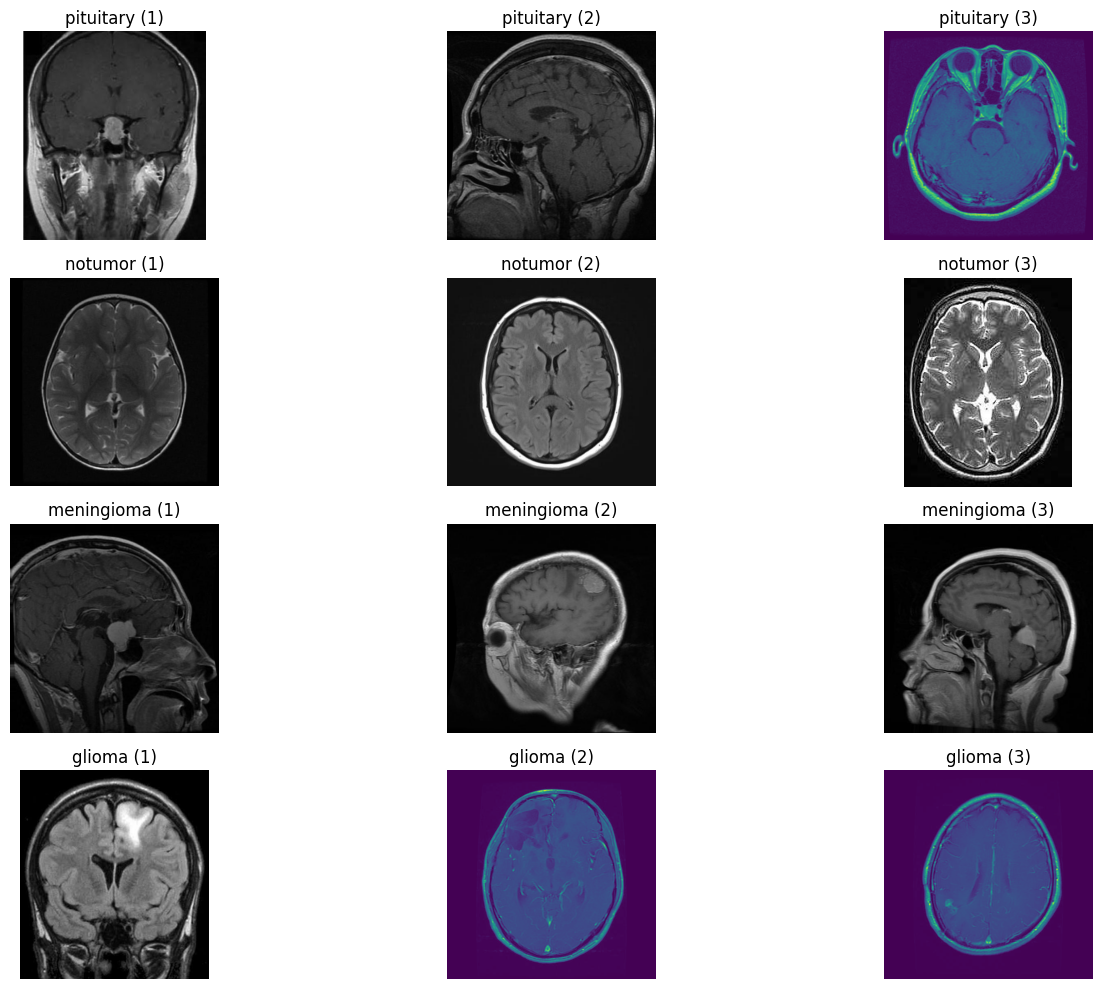

In [6]:

# Get unique labels
labels = dataset_df['label'].unique()

# Set up the plot for visualizing sample images
plt.figure(figsize=(15, 10))

for i, label in enumerate(labels):
    # Get filepaths for the current label
    label_filepaths = dataset_df[dataset_df['label'] == label]['filepath'].tolist()

    # Select a random sample of images (e.g., 3 images per class)
    sample_images_paths = random.sample(label_filepaths, min(3, len(label_filepaths)))

    for j, img_path in enumerate(sample_images_paths):
        plt.subplot(len(labels), 3, i * 3 + j + 1)
        img = Image.open(img_path)
        plt.imshow(img)
        plt.title(f"{label} ({j+1})")
        plt.axis('off')

plt.tight_layout()
plt.show()

### Visualizing Sample Images

### Inspecting Image Dimensions and Color Channels

Image dimensions and color channels are critical attributes that can influence model design and preprocessing. Let's analyze these characteristics across our dataset to identify any inconsistencies or requirements for resizing and normalization.


--- Image Dimensions Analysis ---
Min Width: 173, Max Width: 1280, Mean Width: 455.96
Min Height: 168, Max Height: 872, Mean Height: 455.71
Unique Widths: [ 173  177  192  194  200  201  206  208  211  212  213  214  215  216
  218  224  225  227  228  230  232  235  236  249  256  267  275  291
  300  305  306  341  354  359  380  393  400  405  420  428  440  441
  442  455  472  474  495  504  512  526  534  540  550  562  572  626
  630  642  645  680  785  850  900 1280]
Unique Heights: [168 192 197 201 213 214 216 217 221 222 225 227 229 231 234 235 236 237
 238 239 242 244 250 251 252 256 259 262 280 282 293 300 301 325 328 340
 361 365 372 398 400 417 439 442 443 449 474 484 500 512 530 536 537 540
 568 575 583 592 619 630 664 674 680 720 741 848 872]

--- Color Channels Analysis ---
Unique Number of Channels: [1 3]
Most common channel count: 3 (appears 282 times)


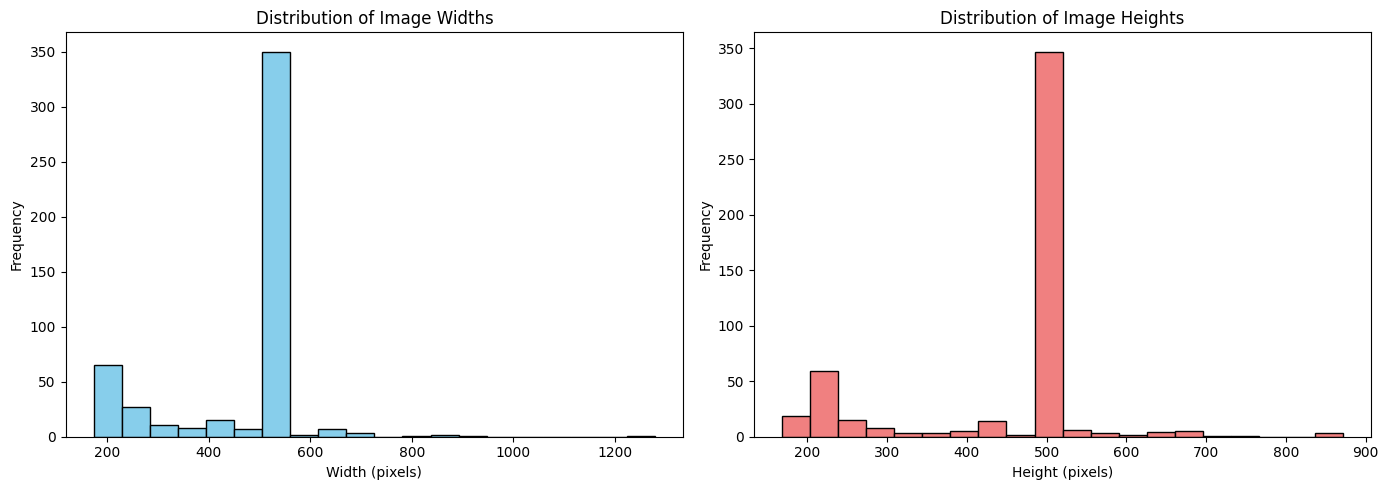

In [7]:

# Initialize lists to store image properties
widths = []
heights = []
channels = []

# Iterate through a sample of filepaths to get properties (to save time, we can sample a subset)
# For a full analysis, iterate through dataset_df['filepath']
# Taking a smaller sample for quick EDA
sample_filepaths = dataset_df['filepath'].sample(n=500, random_state=42).tolist()

for img_path in sample_filepaths:
    try:
        with Image.open(img_path) as img:
            widths.append(img.width)
            heights.append(img.height)

            # Check number of channels
            if img.mode == 'RGB':
                channels.append(3)
            elif img.mode == 'L': # Grayscale
                channels.append(1)
            else:
                channels.append(len(img.getbands())) # Handle other modes
    except Exception as e:
        print(f"Error opening image {img_path}: {e}")

# Convert to numpy arrays for analysis
widths = np.array(widths)
heights = np.array(heights)
channels = np.array(channels)

print("\n--- Image Dimensions Analysis ---")
print(f"Min Width: {widths.min()}, Max Width: {widths.max()}, Mean Width: {widths.mean():.2f}")
print(f"Min Height: {heights.min()}, Max Height: {heights.max()}, Mean Height: {heights.mean():.2f}")
print(f"Unique Widths: {np.unique(widths)}")
print(f"Unique Heights: {np.unique(heights)}")

print("\n--- Color Channels Analysis ---")
print(f"Unique Number of Channels: {np.unique(channels)}")
print(f"Most common channel count: {np.bincount(channels).argmax()} (appears {np.bincount(channels).max()} times)")

# Plotting distribution of dimensions (optional, but good for visual EDA)
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(widths, bins=20, color='skyblue', edgecolor='black')
axes[0].set_title('Distribution of Image Widths')
axes[0].set_xlabel('Width (pixels)')
axes[0].set_ylabel('Frequency')

axes[1].hist(heights, bins=20, color='lightcoral', edgecolor='black')
axes[1].set_title('Distribution of Image Heights')
axes[1].set_xlabel('Height (pixels)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### Inspecting Image Dimensions and Color Channels

### Checking for Corrupted Images

Before proceeding with model training, it's crucial to identify and handle any corrupted or unreadable image files in the dataset. This step ensures data integrity and prevents errors during data loading and preprocessing.

In [8]:

corrupted_images = []

print("Checking for corrupted images across the dataset...")

# Iterate through all image filepaths in the combined dataset_df
for index, row in dataset_df.iterrows():
    img_path = row['filepath']
    try:
        # Attempt to open and verify the image
        with Image.open(img_path) as img:
            img.verify() # Verify if the file is a valid image
    except Exception as e:
        corrupted_images.append({'filepath': img_path, 'error': str(e)})
        # Optional: print progress for large datasets
        # if len(corrupted_images) % 10 == 0:
        #     print(f"Found {len(corrupted_images)} corrupted images so far...")

if corrupted_images:
    print(f"\nFound {len(corrupted_images)} corrupted or unreadable images:")
    for item in corrupted_images:
        print(f"  - {item['filepath']}: {item['error']}")
    print("It is recommended to remove these files or handle them appropriately before proceeding.")
    # Optionally, create a DataFrame for corrupted images
    corrupted_df = pd.DataFrame(corrupted_images)
else:
    print("\nNo corrupted or unreadable images found. The dataset appears to be clean.")

Checking for corrupted images across the dataset...

No corrupted or unreadable images found. The dataset appears to be clean.


### Checking for Corrupted Images

### Image Preprocessing Considerations

Given the variability in image dimensions and color channels identified earlier, preprocessing is a vital step for preparing our dataset for machine learning models. Common preprocessing steps include:

1.  **Resizing:** Standardizing all images to a uniform width and height.
2.  **Normalization:** Scaling pixel values (e.g., to a range of 0-1 or -1 to 1).
3.  **Channel Conversion:** Ensuring all images have a consistent number of channels (e.g., converting all to RGB or grayscale).

Let's demonstrate a basic preprocessing step by resizing a sample of images and converting them to RGB format. This will illustrate how we can handle dimension and channel inconsistencies.

Processing a sample of 5 images to 224x224 pixels and RGB format...
Processing complete. Displaying original vs. processed images.


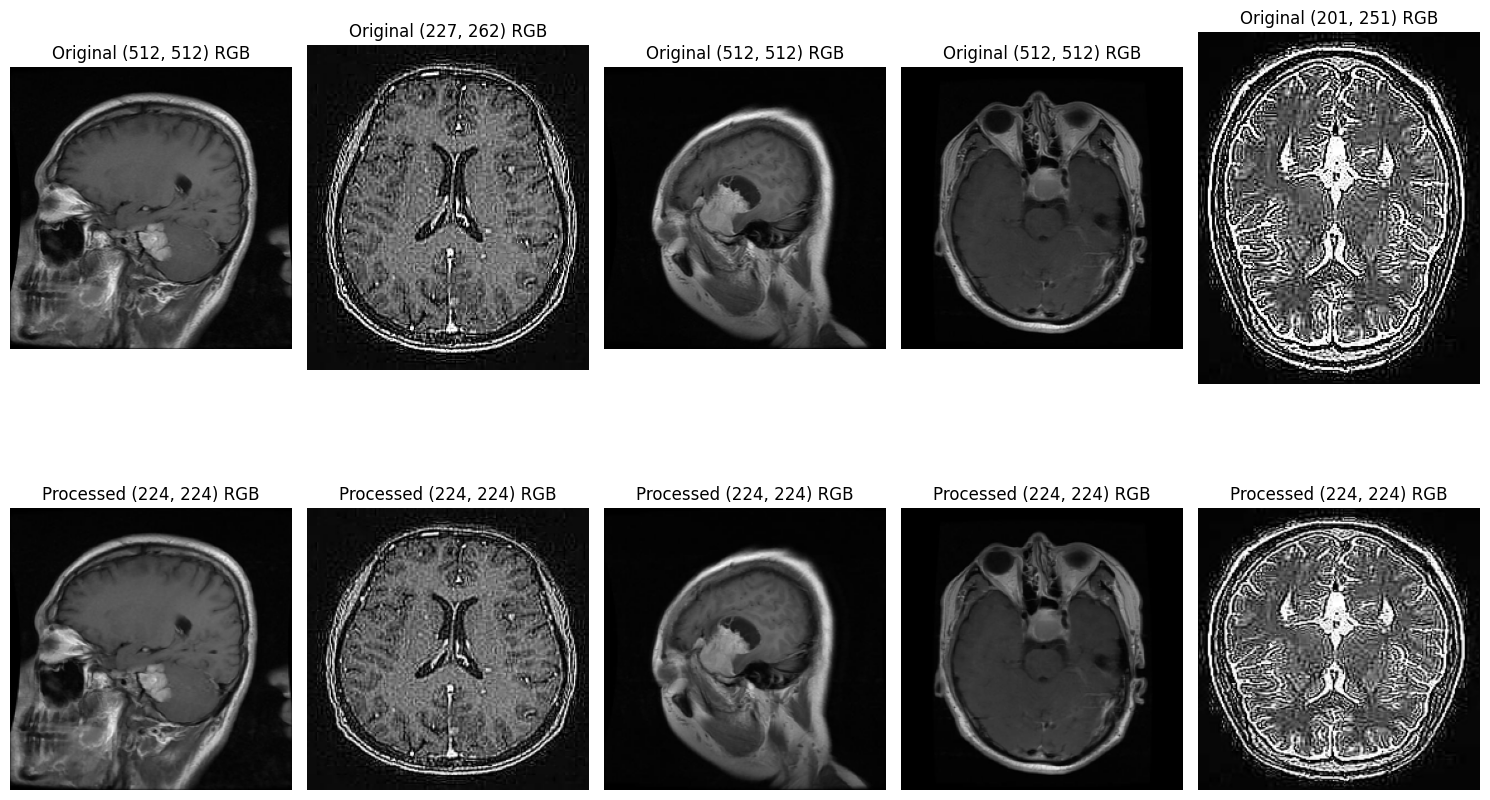


Example: Original image 1 was (512, 512) with mode RGB
Example: Processed image 1 is now (224, 224) with mode RGB


In [9]:

# Define target dimensions and channels
target_size = (224, 224) # Common size for many deep learning models
target_channels = 'RGB' # Convert all to RGB

processed_images_sample = []
original_images_sample = []

print(f"Processing a sample of 5 images to {target_size[0]}x{target_size[1]} pixels and {target_channels} format...")

# Select a small random sample of images for demonstration
sample_paths = dataset_df['filepath'].sample(n=5, random_state=42).tolist()

for img_path in sample_paths:
    try:
        with Image.open(img_path) as img:
            original_images_sample.append(img) # Store original for comparison

            # Convert to target_channels (e.g., RGB) if not already
            if img.mode != target_channels:
                img = img.convert(target_channels)

            # Resize image
            img_resized = img.resize(target_size)
            processed_images_sample.append(img_resized)

    except Exception as e:
        print(f"Error processing image {img_path}: {e}")

print("Processing complete. Displaying original vs. processed images.")

# Display original and processed images side-by-side
plt.figure(figsize=(15, 10))
for i in range(len(sample_paths)):
    # Original Image
    plt.subplot(2, len(sample_paths), i + 1)
    plt.imshow(original_images_sample[i])
    plt.title(f"Original {original_images_sample[i].size} {original_images_sample[i].mode}")
    plt.axis('off')

    # Processed Image
    plt.subplot(2, len(sample_paths), len(sample_paths) + i + 1)
    plt.imshow(processed_images_sample[i])
    plt.title(f"Processed {processed_images_sample[i].size} {processed_images_sample[i].mode}")
    plt.axis('off')

plt.tight_layout()
plt.show()

print(f"\nExample: Original image 1 was {original_images_sample[0].size} with mode {original_images_sample[0].mode}")
print(f"Example: Processed image 1 is now {processed_images_sample[0].size} with mode {processed_images_sample[0].mode}")

### Image Preprocessing Considerations

In [11]:

def analyze_dataset_properties(df):
    widths, heights, channels = [], [], []

    for path in df['filepath']:
        with Image.open(path) as img:
            w, h = img.size
            c = len(img.getbands())
            widths.append(w)
            heights.append(h)
            channels.append(c)

    df['width'] = widths
    df['height'] = heights
    df['channels'] = channels
    df['aspect_ratio'] = df['width'] / df['height']
    return df

# Execute deep inspection
train_df = analyze_dataset_properties(train_df)

print("=== Image Dimensions & Aspect Ratio Summary ===")
print(train_df[['width', 'height', 'aspect_ratio', 'channels']].describe())

# Check channel distribution
print("\n=== Channel Counts ===")
print(train_df['channels'].value_counts())

=== Image Dimensions & Aspect Ratio Summary ===
             width       height  aspect_ratio     channels
count  5600.000000  5600.000000   5600.000000  5600.000000
mean    458.513750   462.262857      0.988435     2.158036
std     129.619399   123.617483      0.079300     0.988335
min     150.000000   168.000000      0.644809     1.000000
25%     512.000000   512.000000      1.000000     1.000000
50%     512.000000   512.000000      1.000000     3.000000
75%     512.000000   512.000000      1.000000     3.000000
max    1375.000000  1446.000000      1.785714     4.000000

=== Channel Counts ===
channels
3    3238
1    2359
4       3
Name: count, dtype: int64


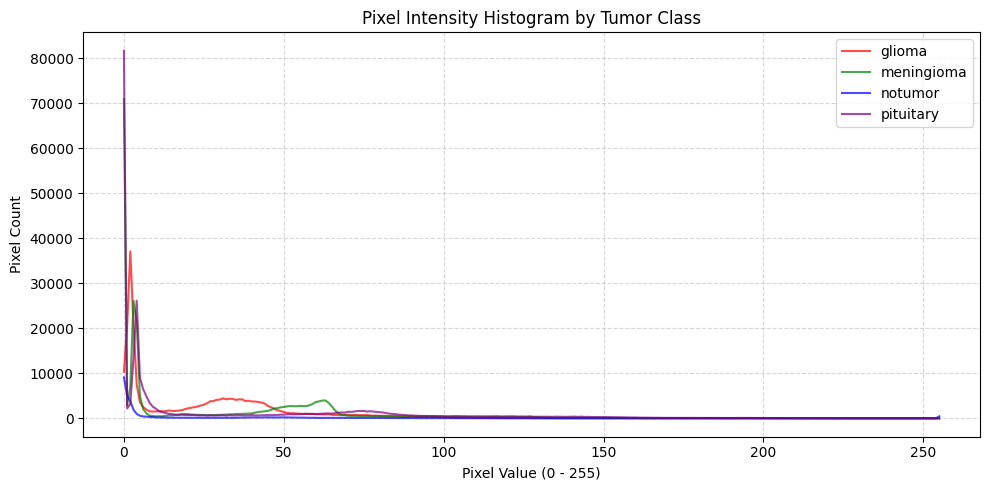

In [13]:
plt.figure(figsize=(10, 5))
colors = {'glioma': 'red', 'meningioma': 'green', 'notumor': 'blue', 'pituitary': 'purple'}

for label, color in colors.items():
    sample_path = train_df[train_df['label'] == label]['filepath'].iloc[0]
    img = cv2.imread(sample_path, cv2.IMREAD_GRAYSCALE)
    hist = cv2.calcHist([img], [0], None, [256], [0, 256])
    plt.plot(hist, color=color, label=label, alpha=0.7)

plt.title("Pixel Intensity Histogram by Tumor Class")
plt.xlabel("Pixel Value (0 - 255)")
plt.ylabel("Pixel Count")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Data Splitting

In [12]:
from sklearn.model_selection import train_test_split

# Create 85% Train / 15% Validation Split from the 5,600 training set
train_data, val_data = train_test_split(
    train_df,
    test_size=0.15,
    random_state=42,
    stratify=train_df['label']
)

print(f"Training Set:   {len(train_data)} images")
print(f"Validation Set: {len(val_data)} images")
print(f"Test Set:       {len(test_df)} images")

Training Set:   4760 images
Validation Set: 840 images
Test Set:       1600 images


## Dataset Class and Transforms

In [14]:

# Mapping text labels to class indices
LABEL_MAP = {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}

class BrainMRIDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]['filepath']
        label_str = self.df.iloc[idx]['label']
        label = LABEL_MAP[label_str]

        # Convert to RGB to ensure 3 channels for ImageNet backbones
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, label





In [40]:
# --- Transforms using Torchvision V2 API ---
train_transform = v2.Compose([
    v2.Resize((224, 224), antialias=True),
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomRotation(degrees=10),
    v2.ColorJitter(brightness=0.1, contrast=0.1),
    v2.ToImage(), # Convert PIL Image to a Tensor Image (uint8)
    v2.ToDtype(torch.float32, scale=True), # Convert to float32 and scale to [0,1]
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_test_transform = v2.Compose([
    v2.Resize((224, 224), antialias=True),
    v2.ToImage(), # Convert PIL Image to a Tensor Image (uint8)
    v2.ToDtype(torch.float32, scale=True), # Convert to float32 and scale to [0,1]
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

## Data Loaders

In [41]:
# --- Create DataLoaders ---
train_dataset = BrainMRIDataset(train_data, transform=train_transform)
val_dataset = BrainMRIDataset(val_data, transform=val_test_transform)
test_dataset = BrainMRIDataset(test_df, transform=val_test_transform)

In [42]:
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

## Model Architecture Definition

In [62]:
def build_model(architecture='resnet50', num_classes=4, pretrained=True):
    if architecture == 'resnet50':
        weights = models.ResNet50_Weights.DEFAULT if pretrained else None
        model = models.resnet50(weights=weights)
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)

    elif architecture == 'efficientnet_b0':
        weights = models.EfficientNet_B0_Weights.DEFAULT if pretrained else None
        model = models.efficientnet_b0(weights=weights)
        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_features, num_classes)

    elif architecture == 'vgg16':
        weights = models.VGG16_Weights.DEFAULT if pretrained else None
        model = models.vgg16(weights=weights)
        # Modify the classifier for our number of classes
        model.classifier[6] = nn.Linear(model.classifier[6].in_features, num_classes)

    else:
        raise ValueError(f"Unsupported architecture: {architecture}")

    return model

## Device Setup and Hyperparameters

In [44]:

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = build_model(architecture='resnet50', num_classes=4, pretrained=True).to(device)



In [29]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

## Training and Validation Loop Functions

In [30]:

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss, correct_preds, total_samples = 0.0, 0, 0

    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct_preds += torch.sum(preds == labels.data).item()
        total_samples += images.size(0)

    return running_loss / total_samples, correct_preds / total_samples





In [31]:
def validate(model, dataloader, criterion, device):
    model.eval()
    running_loss, correct_preds, total_samples = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct_preds += torch.sum(preds == labels.data).item()
            total_samples += images.size(0)

    return running_loss / total_samples, correct_preds / total_samples

## Model Training and Evaluation Wrapper

In [45]:

# Helper function to plot training history
def plot_history(history, model_name):
    epochs = range(1, len(history['train_losses']) + 1)

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_losses'], 'bo-', label='Training Loss')
    plt.plot(epochs, history['val_losses'], 'ro-', label='Validation Loss')
    plt.title(f'{model_name} Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_accs'], 'bo-', label='Training Accuracy')
    plt.plot(epochs, history['val_accs'], 'ro-', label='Validation Accuracy')
    plt.title(f'{model_name} Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Helper function to display evaluation metrics
def display_metrics(all_labels, all_preds, model_name, class_names):
    print(f"\n=== {model_name} Test Set Evaluation ===")
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'{model_name} Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()


def train_and_evaluate_model(model_name, architecture, train_loader, val_loader, test_loader, num_classes, epochs=10):
    print(f"\n--- Training {model_name} ---")
    model = build_model(architecture=architecture, num_classes=num_classes, pretrained=True).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

    history = {
        'train_losses': [], 'train_accs': [],
        'val_losses': [], 'val_accs': []
    }

    best_val_loss = float('inf')
    best_model_path = f'best_{model_name.lower().replace(" ", "_")}_model.pth'

    for epoch in range(epochs):
        start_time = time.time()

        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = validate(model, val_loader, criterion, device)

        scheduler.step(val_loss)
        elapsed = time.time() - start_time

        history['train_losses'].append(train_loss)
        history['train_accs'].append(train_acc)
        history['val_losses'].append(val_loss)
        history['val_accs'].append(val_acc)

        print(f"Epoch [{epoch+1}/{epochs}] | Time: {elapsed:.1f}s")
        print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}%")
        print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc*100:.2f}%")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), best_model_path)
            print(f"  --> Best validation loss improved. Model saved to {best_model_path}")

    print(f"\n--- Finished Training {model_name}. Loading best model for testing ---")
    model.load_state_dict(torch.load(best_model_path))
    model.eval()

    all_preds = []
    all_labels = []
    test_loss = 0.0
    correct_preds = 0
    total_samples = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            test_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            correct_preds += torch.sum(preds == labels.data).item()
            total_samples += images.size(0)

    final_test_loss = test_loss / total_samples
    final_test_acc = correct_preds / total_samples

    print(f"\nTest Loss: {final_test_loss:.4f} | Test Accuracy: {final_test_acc*100:.2f}%")

    return history, all_labels, all_preds, final_test_acc




--- Training ResNet50 ---
Epoch [1/10] | Time: 67.6s
  Train Loss: 0.4039 | Train Acc: 87.42%
  Val Loss:   0.1728 | Val Acc:   92.98%
  --> Best validation loss improved. Model saved to best_resnet50_model.pth
Epoch [2/10] | Time: 67.3s
  Train Loss: 0.1040 | Train Acc: 96.64%
  Val Loss:   0.0805 | Val Acc:   97.74%
  --> Best validation loss improved. Model saved to best_resnet50_model.pth
Epoch [3/10] | Time: 64.4s
  Train Loss: 0.0577 | Train Acc: 97.96%
  Val Loss:   0.0829 | Val Acc:   97.02%
Epoch [4/10] | Time: 66.5s
  Train Loss: 0.0409 | Train Acc: 98.76%
  Val Loss:   0.0600 | Val Acc:   98.57%
  --> Best validation loss improved. Model saved to best_resnet50_model.pth
Epoch [5/10] | Time: 63.3s
  Train Loss: 0.0308 | Train Acc: 98.99%
  Val Loss:   0.0754 | Val Acc:   97.74%
Epoch [6/10] | Time: 63.9s
  Train Loss: 0.0295 | Train Acc: 98.99%
  Val Loss:   0.0614 | Val Acc:   98.10%
Epoch [7/10] | Time: 64.8s
  Train Loss: 0.0264 | Train Acc: 99.08%
  Val Loss:   0.0424 | 

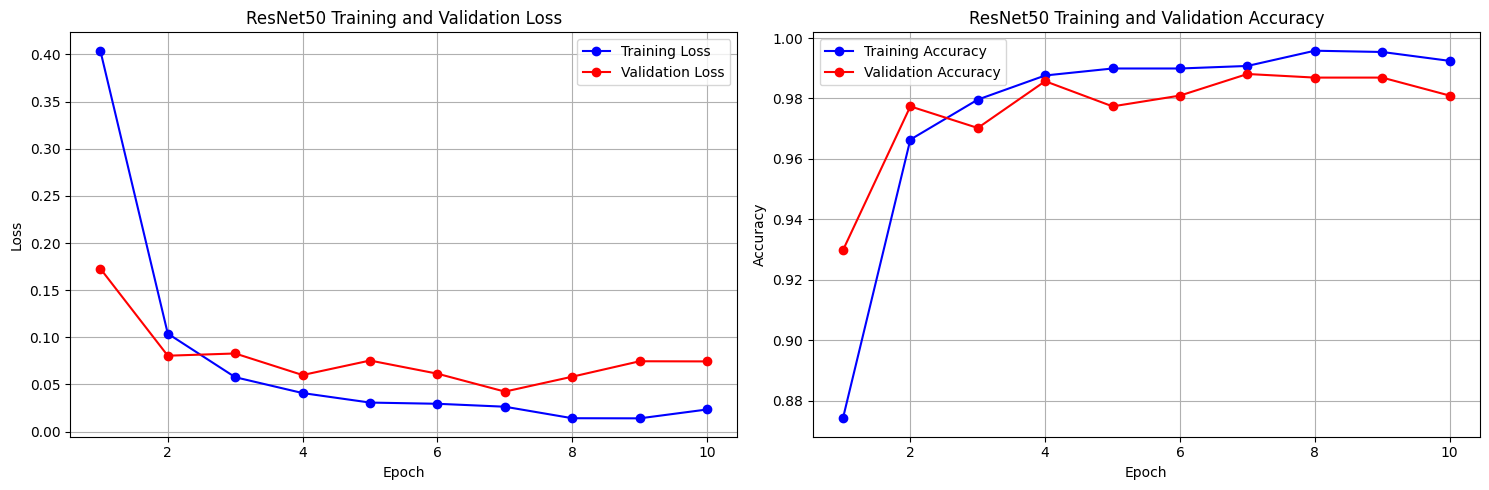


=== ResNet50 Test Set Evaluation ===

Classification Report:
              precision    recall  f1-score   support

      glioma       1.00      0.82      0.90       400
  meningioma       0.91      0.99      0.95       400
     notumor       0.92      0.99      0.96       400
   pituitary       0.99      1.00      1.00       400

    accuracy                           0.95      1600
   macro avg       0.95      0.95      0.95      1600
weighted avg       0.95      0.95      0.95      1600



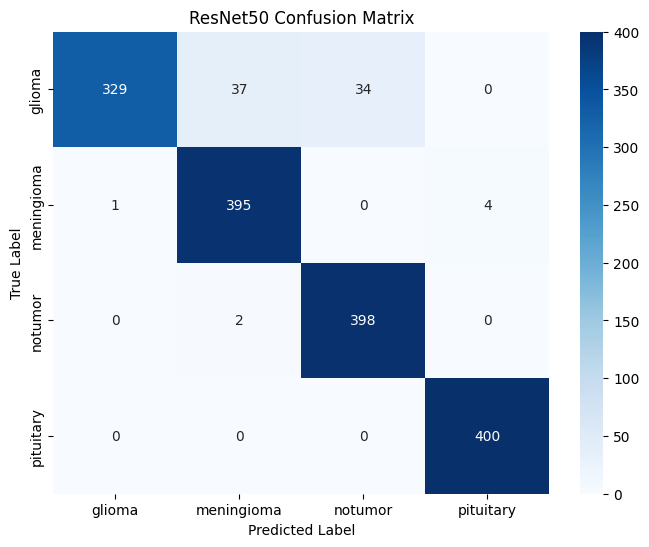


--- Training EfficientNet-B0 ---
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 137MB/s]


Epoch [1/10] | Time: 47.0s
  Train Loss: 0.4808 | Train Acc: 85.29%
  Val Loss:   0.1925 | Val Acc:   93.21%
  --> Best validation loss improved. Model saved to best_efficientnet-b0_model.pth
Epoch [2/10] | Time: 45.8s
  Train Loss: 0.1621 | Train Acc: 94.45%
  Val Loss:   0.0837 | Val Acc:   96.43%
  --> Best validation loss improved. Model saved to best_efficientnet-b0_model.pth
Epoch [3/10] | Time: 46.4s
  Train Loss: 0.0916 | Train Acc: 96.93%
  Val Loss:   0.0514 | Val Acc:   98.10%
  --> Best validation loss improved. Model saved to best_efficientnet-b0_model.pth
Epoch [4/10] | Time: 45.6s
  Train Loss: 0.0605 | Train Acc: 98.07%
  Val Loss:   0.0498 | Val Acc:   97.86%
  --> Best validation loss improved. Model saved to best_efficientnet-b0_model.pth
Epoch [5/10] | Time: 47.0s
  Train Loss: 0.0421 | Train Acc: 98.68%
  Val Loss:   0.0391 | Val Acc:   98.69%
  --> Best validation loss improved. Model saved to best_efficientnet-b0_model.pth
Epoch [6/10] | Time: 46.7s
  Train Loss:

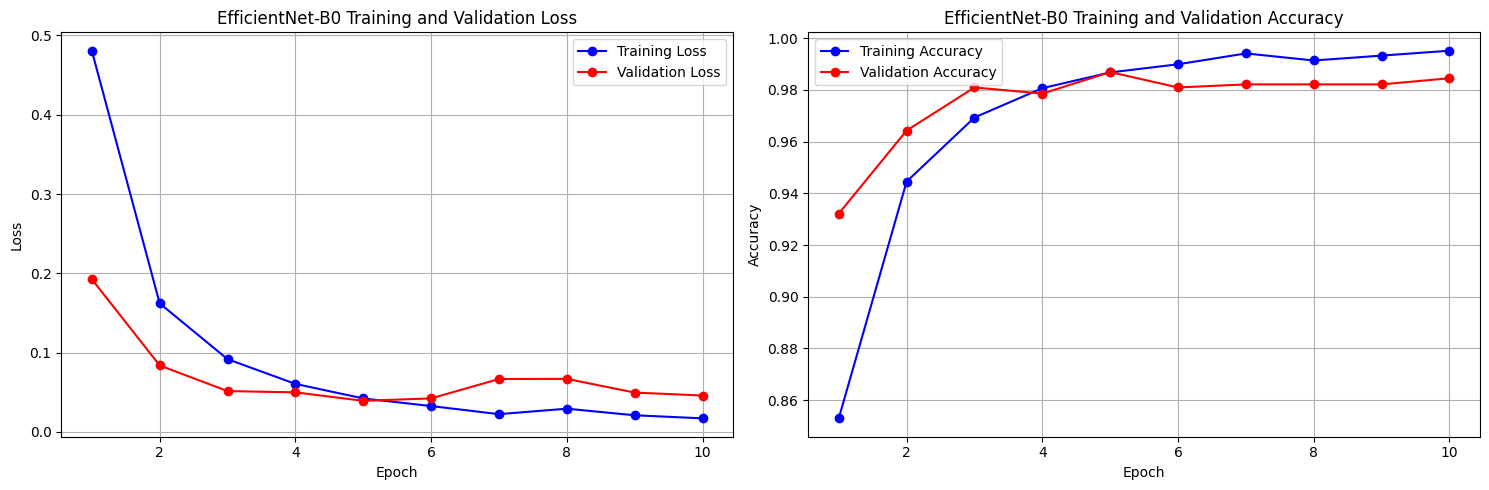


=== EfficientNet-B0 Test Set Evaluation ===

Classification Report:
              precision    recall  f1-score   support

      glioma       0.98      0.83      0.90       400
  meningioma       0.90      0.97      0.94       400
     notumor       0.94      1.00      0.97       400
   pituitary       0.98      0.99      0.99       400

    accuracy                           0.95      1600
   macro avg       0.95      0.95      0.95      1600
weighted avg       0.95      0.95      0.95      1600



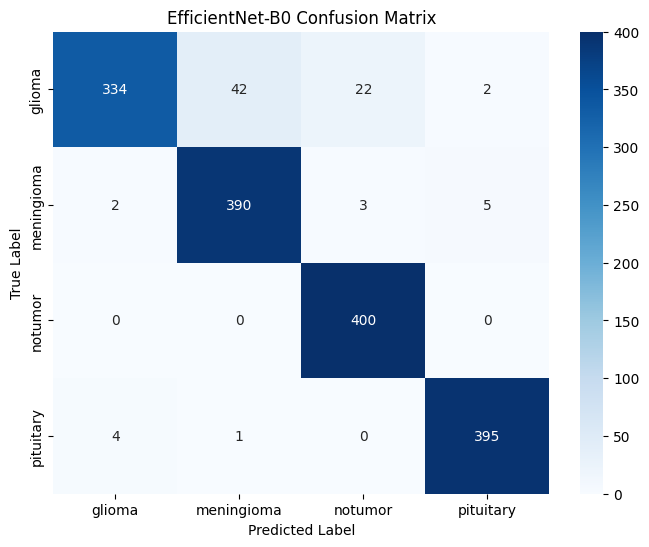


--- Training VGG16 ---
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:04<00:00, 116MB/s]


Epoch [1/10] | Time: 88.4s
  Train Loss: 0.4151 | Train Acc: 84.35%
  Val Loss:   0.1804 | Val Acc:   93.93%
  --> Best validation loss improved. Model saved to best_vgg16_model.pth
Epoch [2/10] | Time: 91.8s
  Train Loss: 0.1904 | Train Acc: 93.78%
  Val Loss:   0.2154 | Val Acc:   92.26%
Epoch [3/10] | Time: 88.8s
  Train Loss: 0.1160 | Train Acc: 96.18%
  Val Loss:   0.0809 | Val Acc:   97.50%
  --> Best validation loss improved. Model saved to best_vgg16_model.pth
Epoch [4/10] | Time: 90.6s
  Train Loss: 0.0674 | Train Acc: 97.79%
  Val Loss:   0.1013 | Val Acc:   96.31%
Epoch [5/10] | Time: 92.5s
  Train Loss: 0.0786 | Train Acc: 97.54%
  Val Loss:   0.1380 | Val Acc:   96.19%
Epoch [6/10] | Time: 91.9s
  Train Loss: 0.0521 | Train Acc: 98.26%
  Val Loss:   0.1171 | Val Acc:   96.43%
Epoch [7/10] | Time: 89.1s
  Train Loss: 0.0166 | Train Acc: 99.54%
  Val Loss:   0.0876 | Val Acc:   98.33%
Epoch [8/10] | Time: 92.5s
  Train Loss: 0.0164 | Train Acc: 99.29%
  Val Loss:   0.0637 | 

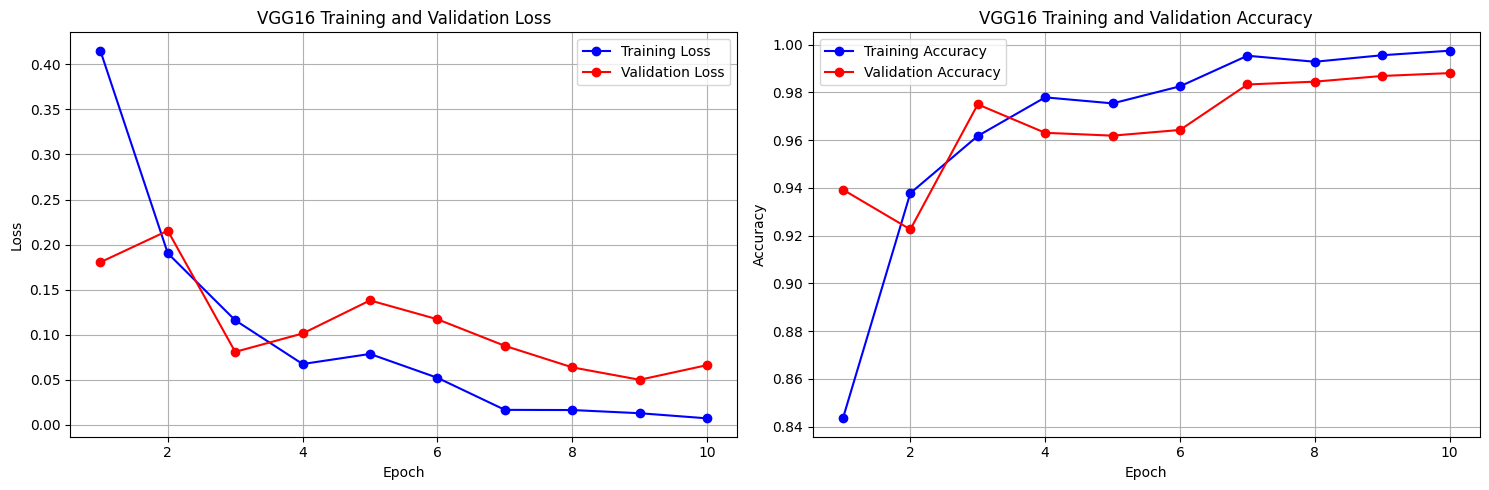


=== VGG16 Test Set Evaluation ===

Classification Report:
              precision    recall  f1-score   support

      glioma       0.99      0.84      0.91       400
  meningioma       0.91      0.98      0.94       400
     notumor       0.94      1.00      0.97       400
   pituitary       0.99      0.99      0.99       400

    accuracy                           0.95      1600
   macro avg       0.96      0.95      0.95      1600
weighted avg       0.96      0.95      0.95      1600



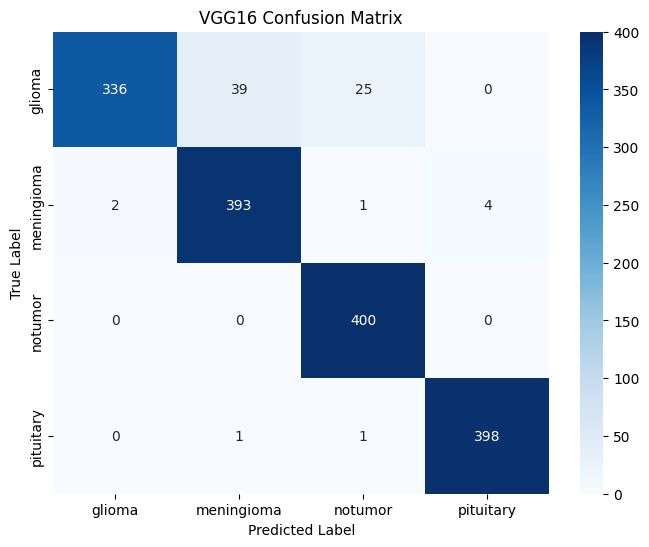



=== Model Performance Summary ===

Model: ResNet50
  Final Test Accuracy: 95.12%

Model: EfficientNet-B0
  Final Test Accuracy: 94.94%

Model: VGG16
  Final Test Accuracy: 95.44%


In [46]:
class_names = list(LABEL_MAP.keys())
NUM_CLASSES = len(class_names)
TRAINING_EPOCHS = 10 # You can adjust this number

model_results = {}

# --- ResNet50 ---
history_resnet, labels_resnet, preds_resnet, acc_resnet = train_and_evaluate_model(
    model_name='ResNet50',
    architecture='resnet50',
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    num_classes=NUM_CLASSES,
    epochs=TRAINING_EPOCHS
)
model_results['ResNet50'] = {'history': history_resnet, 'labels': labels_resnet, 'preds': preds_resnet, 'test_acc': acc_resnet}
plot_history(history_resnet, 'ResNet50')
display_metrics(labels_resnet, preds_resnet, 'ResNet50', class_names)

# --- EfficientNet-B0 ---
history_efficientnet, labels_efficientnet, preds_efficientnet, acc_efficientnet = train_and_evaluate_model(
    model_name='EfficientNet-B0',
    architecture='efficientnet_b0',
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    num_classes=NUM_CLASSES,
    epochs=TRAINING_EPOCHS
)
model_results['EfficientNet-B0'] = {'history': history_efficientnet, 'labels': labels_efficientnet, 'preds': preds_efficientnet, 'test_acc': acc_efficientnet}
plot_history(history_efficientnet, 'EfficientNet-B0')
display_metrics(labels_efficientnet, preds_efficientnet, 'EfficientNet-B0', class_names)

# --- VGG16 ---
history_vgg16, labels_vgg16, preds_vgg16, acc_vgg16 = train_and_evaluate_model(
    model_name='VGG16',
    architecture='vgg16',
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    num_classes=NUM_CLASSES,
    epochs=TRAINING_EPOCHS
)
model_results['VGG16'] = {'history': history_vgg16, 'labels': labels_vgg16, 'preds': preds_vgg16, 'test_acc': acc_vgg16}
plot_history(history_vgg16, 'VGG16')
display_metrics(labels_vgg16, preds_vgg16, 'VGG16', class_names)

# --- Summary Comparison ---
print("\n\n=== Model Performance Summary ===")
for model_name, results in model_results.items():
    print(f"\nModel: {model_name}")
    print(f"  Final Test Accuracy: {results['test_acc']*100:.2f}%")





## GRAD-CAM Heatmaps and Model Saving

## GRAD-CAM Heatmaps and Model Saving

Now, let's visualize where our models are focusing using GRAD-CAM. We'll pick a sample image and generate heatmaps for each of our trained models. Afterwards, we will save the trained model weights to Google Drive.

In [55]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 55.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44285 sha256=088aff038a4e663e8fbd60c3b1bc03ca9cdf2925efbf0dc7fa579df1a33357ff
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [49]:
# Mount Google Drive to save models

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Generating GRAD-CAM for a sample image (True Label: notumor)...


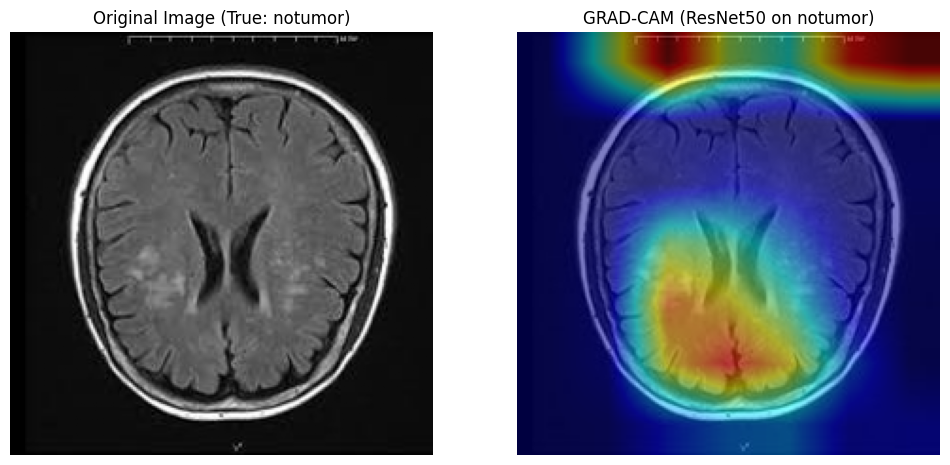

Saved ResNet50 model to Google Drive at: /content/drive/MyDrive/best_resnet50_model.pth


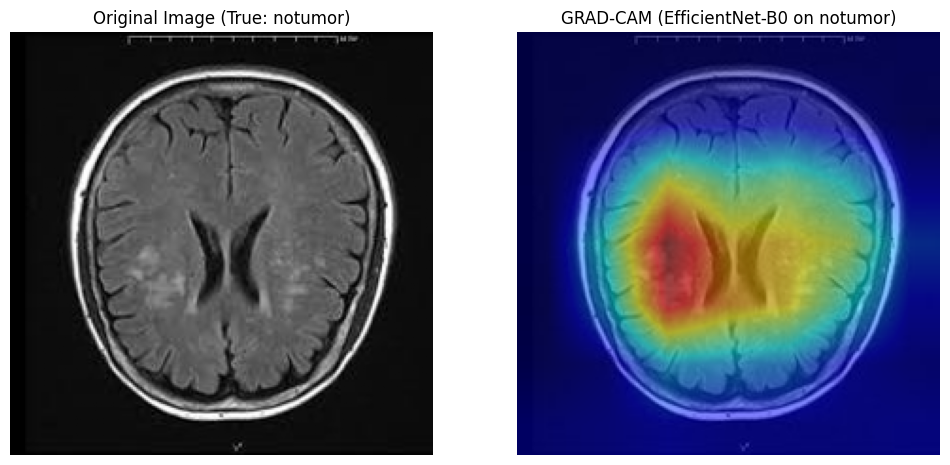

Saved EfficientNet-B0 model to Google Drive at: /content/drive/MyDrive/best_efficientnet-b0_model.pth


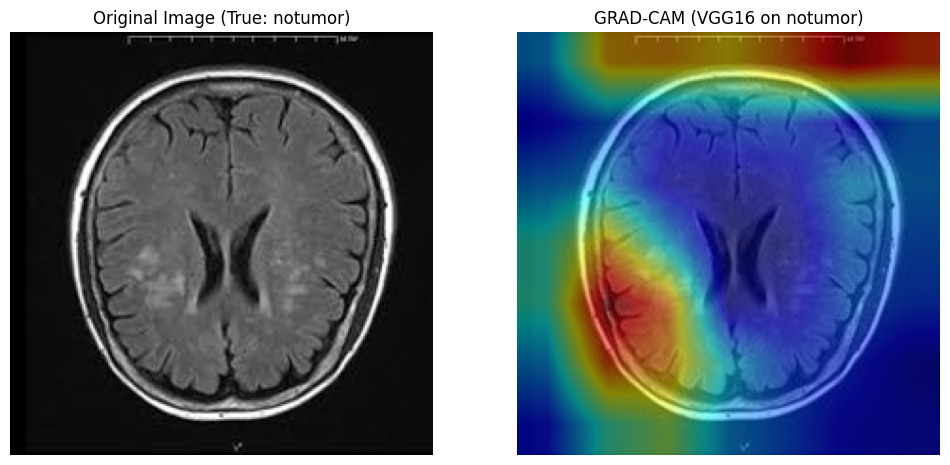

Saved VGG16 model to Google Drive at: /content/drive/MyDrive/best_vgg16_model.pth


In [64]:

# Function to get the target layer for different architectures
def get_target_layer(model_architecture, model):
    if model_architecture == 'resnet50':
        return model.layer4[-1]
    elif model_architecture == 'efficientnet_b0':
        return model.features[-1]
    elif model_architecture == 'vgg16':
        return model.features[-1] # Last conv layer in VGG features
    else:
        raise ValueError("Unsupported model architecture for GRAD-CAM target layer selection")

# Select a random sample image from the test set for visualization
sample_test_idx = random.randint(0, len(test_dataset) - 1)

# Get original image path and label from test_df
sample_image_filepath = test_df.iloc[sample_test_idx]['filepath']
sample_label_idx = LABEL_MAP[test_df.iloc[sample_test_idx]['label']] # Get true label index from df

sample_image_original_pil = Image.open(sample_image_filepath).convert('RGB')

# The image needs to be transformed for the model
transformed_sample_image = val_test_transform(sample_image_original_pil).unsqueeze(0).to(device)

# Convert original PIL image to numpy array for display, ENSURING IT'S RESIZED TO 224x224
# The show_cam_on_image expects the image to be overlaid on to have the same dimensions as the CAM
resized_pil_image = sample_image_original_pil.resize((224, 224))
sample_image_np = np.array(resized_pil_image).astype(np.float32) / 255.0

# Get the true label name
true_label_name = class_names[sample_label_idx]

print(f"Generating GRAD-CAM for a sample image (True Label: {true_label_name})...")

def generate_and_display_grad_cam(model_arch, model_name, model_weights_path, image, true_label_name, target_label_idx):
    model = build_model(architecture=model_arch, num_classes=NUM_CLASSES, pretrained=False) # Load model without pretrained weights first
    model.load_state_dict(torch.load(model_weights_path))
    model = model.to(device)
    model.eval()

    target_layer = get_target_layer(model_arch, model)
    cam = GradCAM(model=model, target_layers=[target_layer]) # Removed use_cuda argument

    # We target the actual class predicted by the model
    targets = [ClassifierOutputTarget(target_label_idx)]

    grayscale_cam = cam(input_tensor=transformed_sample_image, targets=targets)
    grayscale_cam = grayscale_cam[0, :]

    visualization = show_cam_on_image(sample_image_np, grayscale_cam, use_rgb=True)

    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(sample_image_np)
    plt.title(f'Original Image (True: {true_label_name})')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(visualization)
    plt.title(f'GRAD-CAM ({model_name} on {true_label_name})')
    plt.axis('off')
    plt.show()

    return model # Return the loaded model for saving

# --- Iterate through each model to generate GRAD-CAM and save ---
saved_models = {}
for arch, result_data in model_results.items():
    model_weights_filename = f'best_{arch.lower().replace(" ", "_")}_model.pth'
    model_path = os.path.join('/content/', model_weights_filename)

    # Get model's prediction for the sample image
    # Correct the architecture string for 'efficientnet-b0' to 'efficientnet_b0'
    corrected_arch_name = arch.lower().replace(" ", "").replace("-", "_")
    model_temp = build_model(architecture=corrected_arch_name, num_classes=NUM_CLASSES, pretrained=False)
    model_temp.load_state_dict(torch.load(model_path))
    model_temp.to(device).eval()

    with torch.no_grad():
        output = model_temp(transformed_sample_image)
        predicted_label_idx = torch.argmax(output).item()

    loaded_model = generate_and_display_grad_cam(
        model_arch=corrected_arch_name, # Ensure architecture name matches build_model
        model_name=arch,
        model_weights_path=model_path,
        image=transformed_sample_image,
        true_label_name=true_label_name,
        target_label_idx=predicted_label_idx # Use predicted label for CAM to see what it focused on for its decision
    )
    saved_models[arch] = loaded_model

    # Save the best model to Google Drive
    drive_save_path = f'/content/drive/MyDrive/best_{arch.lower().replace(" ", "_")}_model.pth'
    torch.save(loaded_model.state_dict(), drive_save_path)
    print(f"Saved {arch} model to Google Drive at: {drive_save_path}")

### Evaluation Metrics for EfficientNet-B0

### Evaluation Metrics for EfficientNet-B0

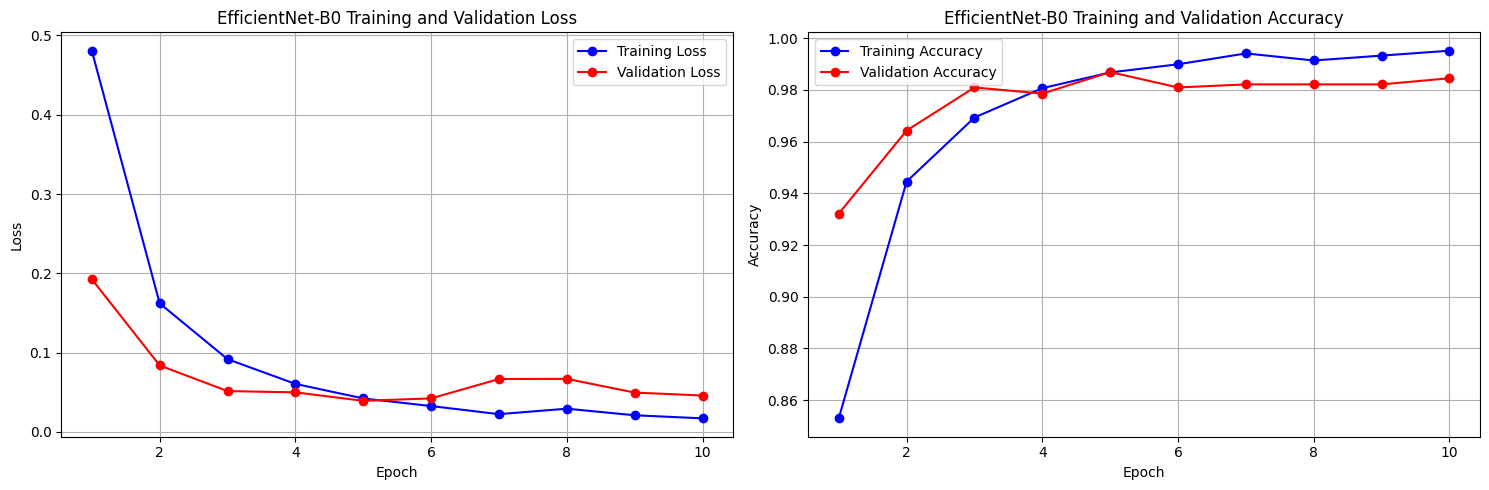


=== EfficientNet-B0 Test Set Evaluation ===

Classification Report:
              precision    recall  f1-score   support

      glioma       0.98      0.83      0.90       400
  meningioma       0.90      0.97      0.94       400
     notumor       0.94      1.00      0.97       400
   pituitary       0.98      0.99      0.99       400

    accuracy                           0.95      1600
   macro avg       0.95      0.95      0.95      1600
weighted avg       0.95      0.95      0.95      1600



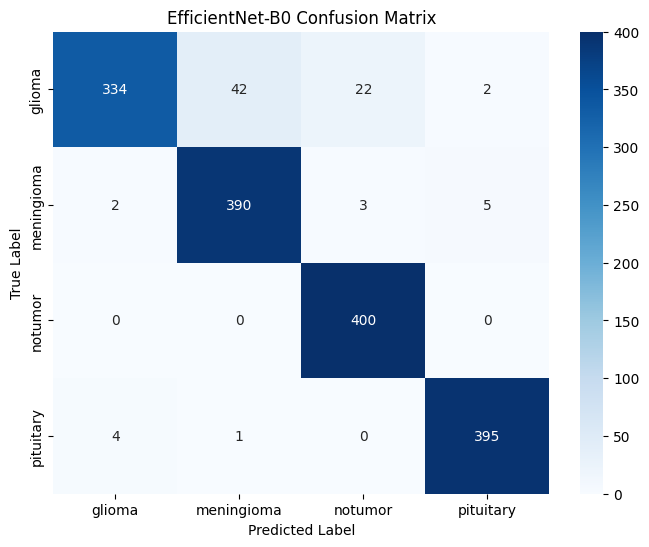

In [65]:
plot_history(model_results['EfficientNet-B0']['history'], 'EfficientNet-B0')
display_metrics(model_results['EfficientNet-B0']['labels'], model_results['EfficientNet-B0']['preds'], 'EfficientNet-B0', class_names)

### Evaluation Metrics for VGG16

### Evaluation Metrics for VGG16

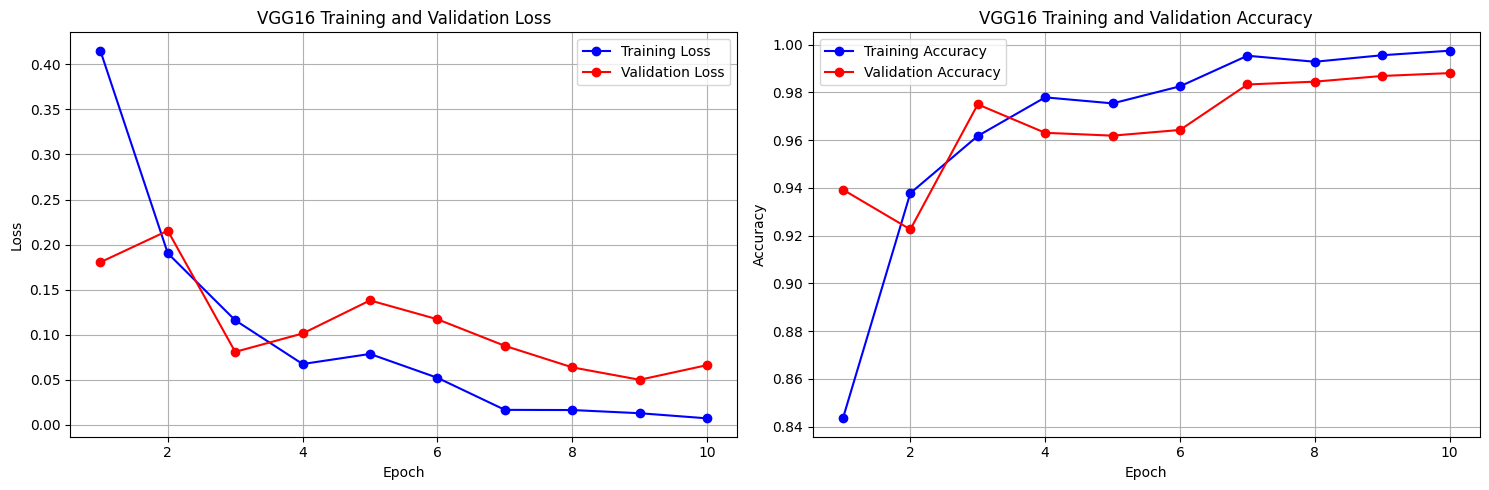


=== VGG16 Test Set Evaluation ===

Classification Report:
              precision    recall  f1-score   support

      glioma       0.99      0.84      0.91       400
  meningioma       0.91      0.98      0.94       400
     notumor       0.94      1.00      0.97       400
   pituitary       0.99      0.99      0.99       400

    accuracy                           0.95      1600
   macro avg       0.96      0.95      0.95      1600
weighted avg       0.96      0.95      0.95      1600



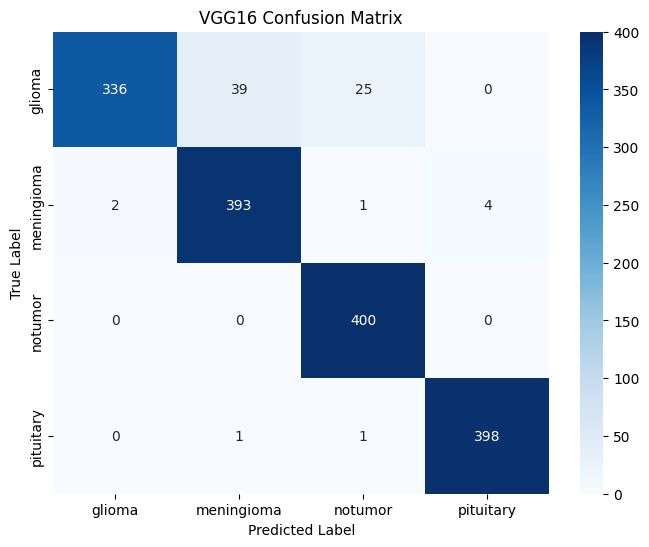

In [66]:
plot_history(model_results['VGG16']['history'], 'VGG16')
display_metrics(model_results['VGG16']['labels'], model_results['VGG16']['preds'], 'VGG16', class_names)

### Comprehensive Model Comparison

### Comprehensive Model Comparison

In [68]:


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

model_comparison_data = []

for model_name, results in model_results.items():
    # Re-build the model to count parameters accurately
    # Ensure the architecture name matches the build_model function's expectation
    corrected_arch_name = model_name.lower().replace(" ", "").replace("-", "_")

    # Load the best model weights into a new model instance for parameter counting
    # No need to load to device for parameter counting
    model_instance = build_model(architecture=corrected_arch_name, num_classes=NUM_CLASSES, pretrained=False)

    num_params = count_parameters(model_instance)

    # Retrieve F1-score, Recall, and Precision directly from the classification report dictionary
    report_dict = classification_report(results['labels'], results['preds'], target_names=class_names, output_dict=True)

    macro_precision = report_dict['macro avg']['precision']
    macro_recall = report_dict['macro avg']['recall']
    macro_f1_score = report_dict['macro avg']['f1-score']

    model_comparison_data.append({
        'Model': model_name,
        'Test Accuracy': f"{results['test_acc']*100:.2f}%",
        'Parameters': f"{num_params:,}",
        'Macro Precision': f"{macro_precision:.2f}",
        'Macro Recall': f"{macro_recall:.2f}",
        'Macro F1-Score': f"{macro_f1_score:.2f}"
    })

comparison_df = pd.DataFrame(model_comparison_data)

print("\n--- Model Performance and Complexity Comparison ---")
print(comparison_df.to_markdown(index=False))



--- Model Performance and Complexity Comparison ---
| Model           | Test Accuracy   | Parameters   |   Macro Precision |   Macro Recall |   Macro F1-Score |
|:----------------|:----------------|:-------------|------------------:|---------------:|-----------------:|
| ResNet50        | 95.12%          | 23,516,228   |              0.95 |           0.95 |             0.95 |
| EfficientNet-B0 | 94.94%          | 4,012,672    |              0.95 |           0.95 |             0.95 |
| VGG16           | 95.44%          | 134,276,932  |              0.96 |           0.95 |             0.95 |
